# Business Understanding

In the modern digital era (circa 2026), the rapid expansion of machine learning has significantly influenced how surveillance is conducted.This project is inspired by the legal precedent established in Terry v. Ohio, which introduced the concept of “reasonable suspicion” in stop-and-frisk practices. While originally rooted in human judgment, similar decision-making processes are now being translated into algorithmic systems. This raises important questions about how historical data, when used to train machine learning models, may shape modern surveillance outcomes.

## Business Objective
The primary objective of this project is to explore the impact of using historically grounded policing datasets to train machine learning models in a digital surveillance context. 

## Stakeholders
The key stakeholders in this context include:

1.Law Enforcement Agencies – Seeking to improve efficiency and consistency in decision-making through data-driven tools.

2.Government & Policymakers – Responsible for regulating surveillance technologies and ensuring alignment with legal frameworks.

3.Technology Companies – Building and deploying machine learning systems used in surveillance and analytics.

4.Civil Rights Organizations – Evaluating fairness, accountability, and potential discrimination in algorithmic systems.

5.General Public – Individuals who may be directly or indirectly affected by automated surveillance decisions.

## Business Problem
The project focuses on :

​. Pattern Identification: Analyzing variables used to justify "reasonable suspicion" decisions .

. ​Predictive Modeling: Training classifiers to predict stop outcomes based on observed variables like officer gender ,subject perceived race  and stop location


# Data Understanding
​The dataset used for this project is the Terry Stops dataset, provided by the City of Seattle via the Seattle Police Department (SPD) Open Data portal. This dataset contains records of police-reported stops under the legal precedent of Terry v. Ohio. Each of the 66,800+ rows represents a unique stop, providing a granular look at law enforcement interactions in Seattle from 2017 through early 2026.

## ​Data Source
​Publisher: Seattle Police Department
​Update Frequency: Daily (last updated March 16, 2026)
​Scope: Records include perceived demographics of the subject, officer demographics, and specific call details from the Computer-Aided Dispatch (CAD) system.

## Target Variable

​To address the business problem of predicting stop outcomes and identifying patterns in "reasonable suspicion," the primary target for our machine learning model is:

​Stop Resolution: This categorical feature describes the final outcome of the stop (e.g., Arrest, Field Contact, Offense Report, or no action taken). Predicting this allows us to understand which variables most strongly correlate with high-stakes outcomes like arrests.

## ​Predictor Variables (Features)

​The dataset provides 23 columns that serve as predictors to help the model identify patterns. Key features include:

​Subject Demographics: Subject Age Group, Subject Perceived Race, and Subject Perceived Gender.

​Officer Demographics: Officer Race, Officer Gender, and Officer YOB (Year of Birth/Experience).

​Contextual/Environmental Data: Precinct, Sector, Beat, and Occurred Date (to capture time-based trends).

​Stop Specifics: Weapon Type (if any), Arrest Flag, Frisk Flag, and Initial Call Type (why the stop was initiated).

​Note on Data Ethics: Because this data relies on "perceived" demographics reported by officers, the analysis focuses on the impact of these perceptions and potential biases within the recorded data rather than an objective demographic census.

# Data Preparation

In [49]:
# import the relevant libraries
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import accuracy_score, roc_curve, auc,classification_report,confusion_matrix,ConfusionMatrixDisplay,roc_auc_score
from sklearn import tree 
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

df = pd.read_csv('Terry_Stops.csv')
df.head()

,Subject Age Group,Subject ID,GO / SC Num,Terry Stop ID,Stop Resolution,Weapon Type,Officer ID,Officer YOB,Officer Gender,Officer Race,...,Initial Call Type,Final Call Type,Call Type,Officer Squad,Arrest Flag,Frisk Flag,Precinct,Sector,Beat,Occurred Date
0,46 - 55,7729078044,2.023000e+13,51923259552,Field Contact,-,4494,1961,Male,White,...,DISTURBANCE,MISCHIEF OR NUISANCE - GENERAL,911,CRG - SQUAD 81D,N,Y,Southwest,W,W1,2023-08-16T20:31:00
1,36 - 45,7727706299,2.025000e+13,63109655222,Field Contact,-,8974,1997,Female,White,...,SUSPICIOUS STOP - OFFICER INITIATED ONVIEW,SUSPICIOUS CIRCUM. - SUSPICIOUS PERSON,ONVIEW,NORTH PCT 2ND W - BOY (JOHN) - PLATOON 1,N,N,North,U,U2,2025-03-08T17:58:00
2,-,31629429379,2.022000e+13,31629401025,Field Contact,Knife/Cutting/Stabbing Instrument,6885,1976,Male,Asian,...,DISTURBANCE,SUSPICIOUS CIRCUM. - SUSPICIOUS PERSON,ONVIEW,WEST PCT 2ND W - SPECIAL BEATS,N,Y,West,M,M2,2022-02-15T17:42:00
3,46 - 55,7746702884,2.021000e+13,25601408632,Arrest,-,8696,1996,Male,White,...,SUSPICIOUS STOP - OFFICER INITIATED ONVIEW,WARRANT SERVICES - MISDEMEANOR,ONVIEW,NORTH PCT 3RD W - B/N RELIEF,Y,N,North,N,N2,2021-06-18T00:48:00
4,17-Jan,-1,2.017000e+13,301638,Arrest,NaN,7773,1978,Male,White,...,OBS - FIGHT - IP - PHYSICAL (NO WEAPONS),"ASSAULTS, OTHER",911,NORTH PCT 3RD W - B/N RELIEF,N,N,North,L,L3,2017-08-27T03:18:00


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66786 entries, 0 to 66785
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Subject Age Group         66786 non-null  object 
 1   Subject ID                66786 non-null  int64  
 2   GO / SC Num               66786 non-null  float64
 3   Terry Stop ID             66786 non-null  int64  
 4   Stop Resolution           66786 non-null  object 
 5   Weapon Type               34221 non-null  object 
 6   Officer ID                66786 non-null  object 
 7   Officer YOB               66786 non-null  int64  
 8   Officer Gender            66786 non-null  object 
 9   Officer Race              66786 non-null  object 
 10  Subject Perceived Race    66786 non-null  object 
 11  Subject Perceived Gender  66786 non-null  object 
 12  Reported Date             66786 non-null  object 
 13  Initial Call Type         66786 non-null  object 
 14  Final 

In [51]:
df.shape

(66786, 23)

In [52]:
# drop unnecessary columns
cols_to_drop = ['Subject ID','GO / SC Num','Terry Stop ID','Officer ID','Reported Date','Officer Squad','Precinct','Sector','Beat','Initial Call Type','Final Call Type','Call Type','Arrest Flag','Frisk Flag']
df = df.drop(columns=cols_to_drop)

# create binary target
df['target'] = df['Stop Resolution'].map(lambda x : 1 if x == 'Arrest' else 0)
no_weapon = ['-','None','NaN']
df['weapon_binary'] = df['Weapon Type'].apply(lambda x : 0 if (str(x) in no_weapon or pd.isna(x))else 1 )

#  First, fix the 'Date' error in the Age Group
df['Subject Age Group'] = df['Subject Age Group'].replace('17-Jan', '1 - 17')

# identify all categorical columns you are keeping
categorical_cols = df.select_dtypes(include=['object']).columns

# Fill any remaining NaNs with 'Unknown' 
df[categorical_cols] = df[categorical_cols].fillna('Unknown')

# 4. Check one last time - everything should be 66786
print(df.isnull().sum())

Subject Age Group           0
Stop Resolution             0
Weapon Type                 0
Officer YOB                 0
Officer Gender              0
Officer Race                0
Subject Perceived Race      0
Subject Perceived Gender    0
Occurred Date               0
target                      0
weapon_binary               0
dtype: int64


In [53]:
# 1. Convert the column to a datetime object
df['Occurred Date'] = pd.to_datetime(df['Occurred Date'])

# 2. Extract the hour (0-23) into a new numerical column
df['Stop_Hour'] = df['Occurred Date'].dt.hour

# 3.Create time-of-day buckets from Stop_Hour
def assign_time_bucket(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Late Night'  # 21–4

df['Time_of_Day'] = df['Stop_Hour'].apply(assign_time_bucket)

# 4. Drop the raw hour column — replaced by the bucket
df = df.drop(columns=['Stop_Hour','Occurred Date'])



## Univariate and Bivariate Analysis

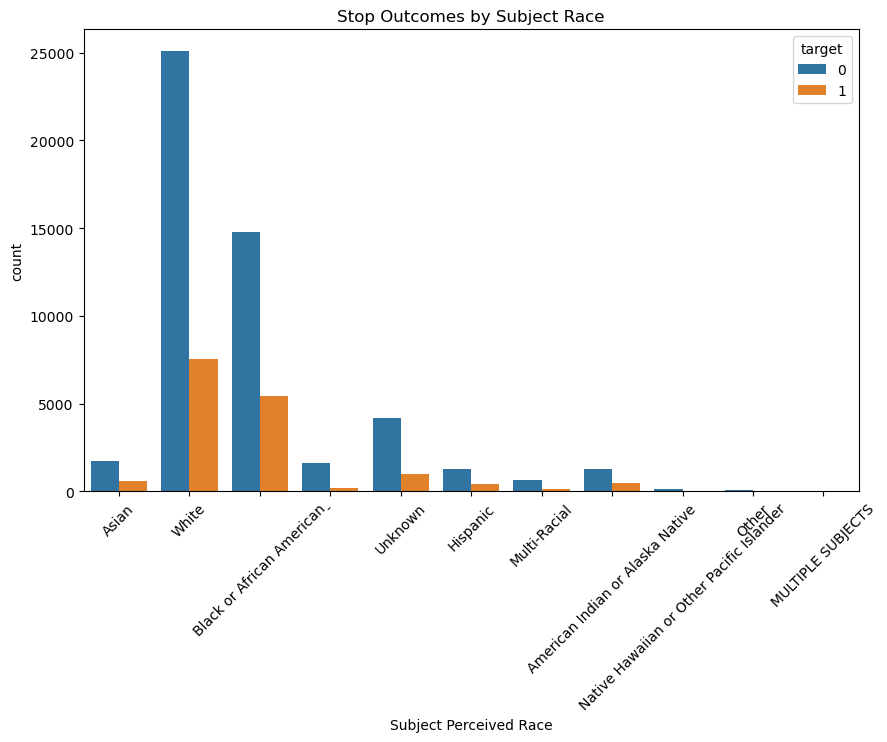

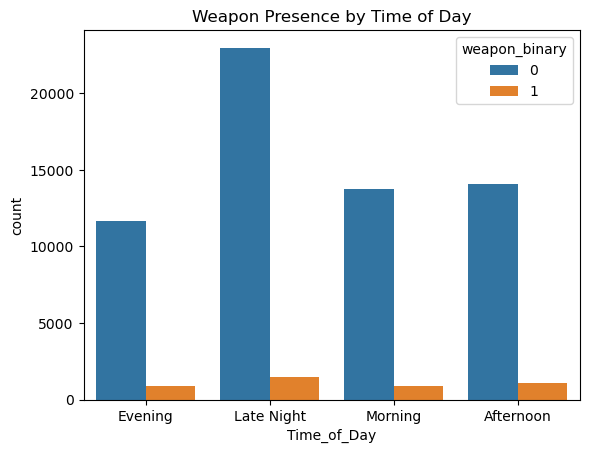

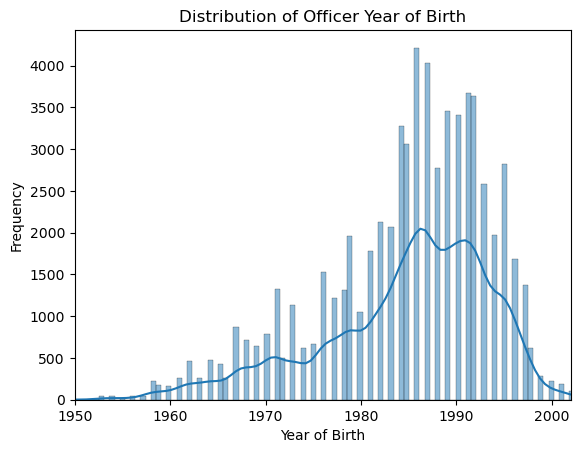

In [54]:
# univariate and bivariate analysis

plt.figure(figsize=(10,6))
sns.countplot(data=df,x='Subject Perceived Race',hue='target')
plt.xticks(rotation=45)
plt.title('Stop Outcomes by Subject Race')
plt.show()

sns.countplot(data=df,x='Time_of_Day',hue='weapon_binary')
plt.title('Weapon Presence by Time of Day')
plt.show()

ax=sns.histplot(df['Officer YOB'],kde=True)
ax.set_xlim(1950,2002)
plt.title('Distribution of Officer Year of Birth')
plt.xlabel('Year of Birth')
plt.ylabel('Frequency')
plt.show()

In [55]:
X = df.drop(columns=['Stop Resolution','target','Weapon Type'])
y = df['target']

X_train , X_test ,y_train , y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [56]:
cat_cols = ['Subject Age Group', 'Officer Gender', 'Officer Race','Subject Perceived Race', 'Subject Perceived Gender','Time_of_Day']

num_col = ['Officer YOB']

# 1. Initialize the transformer
preprocessor = ColumnTransformer(
    transformers=[
        # Apply OneHotEncoding to categorical features
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), cat_cols),
        
        # Apply Scaling to numerical features
        ('num', StandardScaler(), num_col)
    ],
    remainder='passthrough' # This keeps columns like 'weapon_binary' which are already 0/1
)

# 2. Fit and transform the training data
X_train_transformed = preprocessor.fit_transform(X_train)

# 3. Transform the test data 
X_test_transformed = preprocessor.transform(X_test)


In [57]:
# Get the new column names created by the encoder
ohe_colnames = preprocessor.get_feature_names_out()

# Create a nice-looking DataFrame
X_train_final = pd.DataFrame(X_train_transformed, columns=ohe_colnames)

X_train_final.head()


,cat__Subject Age Group_1 - 17,cat__Subject Age Group_18 - 25,cat__Subject Age Group_26 - 35,cat__Subject Age Group_36 - 45,cat__Subject Age Group_46 - 55,cat__Subject Age Group_56 and Above,cat__Officer Gender_Male,cat__Officer Gender_Non-Specified,cat__Officer Race_Asian,cat__Officer Race_Black or African American,...,cat__Subject Perceived Gender_Gender Diverse (gender non-conforming and/or transgender),cat__Subject Perceived Gender_MULTIPLE SUBJECTS,cat__Subject Perceived Gender_Male,cat__Subject Perceived Gender_Unable to Determine,cat__Subject Perceived Gender_Unknown,cat__Time_of_Day_Evening,cat__Time_of_Day_Late Night,cat__Time_of_Day_Morning,num__Officer YOB,remainder__weapon_binary
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.897847,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.005535,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.574783,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.036344,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.036344,0.0


# Modelling

## Model 1. Baseline logistic regression

In [58]:
logreg_base = LogisticRegression(max_iter=1000)
logreg_base.fit(X_train_final,y_train)

X_test_final = pd.DataFrame(X_test_transformed,columns=ohe_colnames)
y_pred_base = logreg_base.predict(X_test_final)


## Model 2. Tuned logistic regression 

There is a class imbalance in the target column , I use SMOTE (synthetic minority oversampling) to address this issue.

In [59]:
df['target'].value_counts()

target
0    50861
1    15925
Name: count, dtype: int64

In [60]:
smote = SMOTE()
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_final, y_train) 

In [61]:
logreg_balanced = LogisticRegression(max_iter=1000)
logreg_balanced.fit(X_train_resampled, y_train_resampled)
y_pred_bal = logreg_balanced.predict(X_test_final)

## Model 3. Decision Tree


In [62]:
dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced',criterion='entropy')
dt_model.fit(X_train_resampled, y_train_resampled)
y_pred_tree = dt_model.predict(X_test_final)

# Evaluation

--- Model 2: Tuned Logistic Regression ---
              precision    recall  f1-score   support

           0       0.81      0.54      0.65     15285
           1       0.29      0.59      0.39      4751

    accuracy                           0.56     20036
   macro avg       0.55      0.57      0.52     20036
weighted avg       0.69      0.56      0.59     20036


--- Model 3: Decision Tree ---
              precision    recall  f1-score   support

           0       0.81      0.36      0.50     15285
           1       0.26      0.73      0.38      4751

    accuracy                           0.45     20036
   macro avg       0.54      0.54      0.44     20036
weighted avg       0.68      0.45      0.47     20036



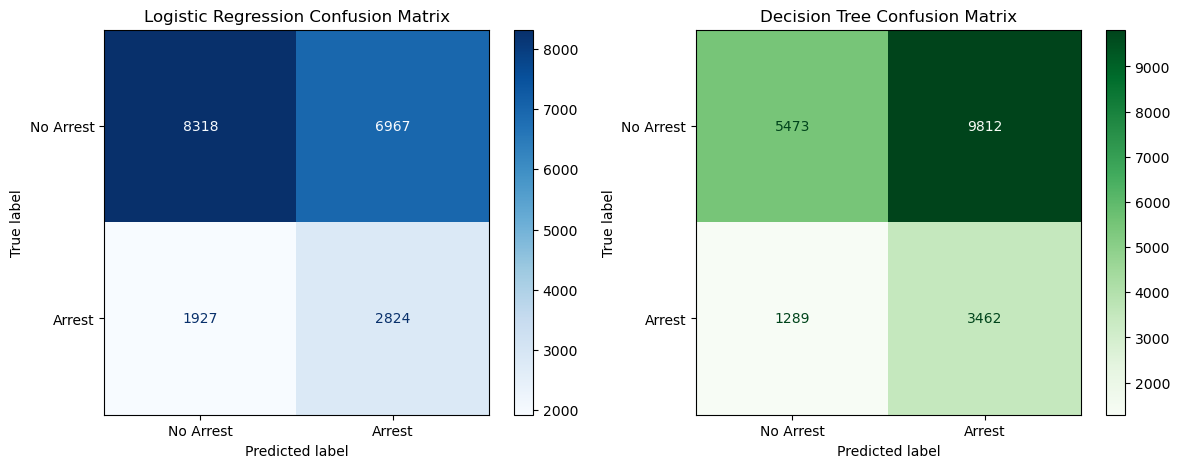

In [63]:
# 1. Classification Reports
print("--- Model 2: Tuned Logistic Regression ---")
print(classification_report(y_test, y_pred_bal))

print("\n--- Model 3: Decision Tree ---")
print(classification_report(y_test, y_pred_tree))

# 2. Plotting Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_bal, 
    display_labels=["No Arrest", "Arrest"], 
    cmap='Blues', ax=ax[0]
)
ax[0].set_title("Logistic Regression Confusion Matrix")

# Decision Tree Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tree, 
    display_labels=["No Arrest", "Arrest"], 
    cmap='Greens', ax=ax[1]
)
ax[1].set_title("Decision Tree Confusion Matrix")

plt.show()


<Axes: title={'center': 'Top 10 Features Predicting Arrest'}>

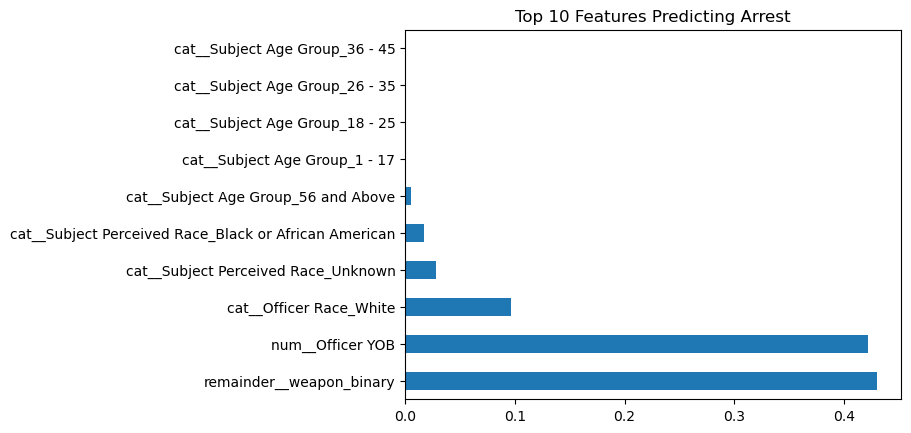

In [64]:
# Get feature importance from the tree
importances = pd.Series(dt_model.feature_importances_, index=X_train_final.columns)
importances.nlargest(10).plot(kind='barh', title='Top 10 Features Predicting Arrest')

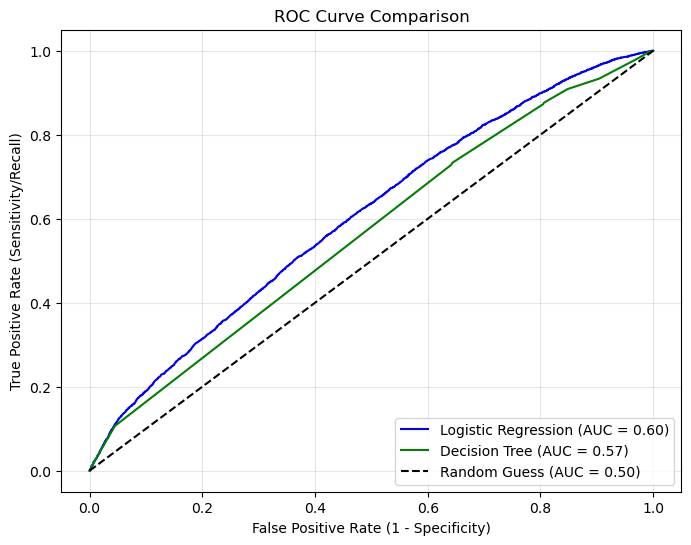

In [65]:
# 1. Get predicted probabilities for the 'positive' class (Arrest = 1)
# Logistic Regression
y_prob_bal = logreg_balanced.predict_proba(X_test_final)[:, 1]
# Decision Tree
y_prob_tree = dt_model.predict_proba(X_test_final)[:, 1]

# 2. Calculate ROC Curve values
fpr_bal, tpr_bal, _ = roc_curve(y_test, y_prob_bal)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)

# 3. Calculate AUC Scores
auc_bal = roc_auc_score(y_test, y_prob_bal)
auc_tree = roc_auc_score(y_test, y_prob_tree)

# 4. Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr_bal, tpr_bal, label=f'Logistic Regression (AUC = {auc_bal:.2f})', color='blue')
plt.plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC = {auc_tree:.2f})', color='green')

# Plot the "Random Guess" baseline (diagonal line)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity/Recall)')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


In [66]:
cv_scores = cross_val_score(dt_model, X_train_resampled, y_train_resampled, cv=5, scoring='recall')

print(f"Cross-Validation Recall Scores: {cv_scores}")
print(f"Mean Recall: {cv_scores.mean():.2f}")
print(f"Standard Deviation: {cv_scores.std():.2f}")

Cross-Validation Recall Scores: [0.73000703 0.75337268 0.78763176 0.77821504 0.78046381]
Mean Recall: 0.77
Standard Deviation: 0.02
